<a href="https://colab.research.google.com/github/EA88837/Siamese-Networks-for-Image-Similarity-Task/blob/main/pgmprojectMINST101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [183]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Install pgmpy library if not already installed
!pip install pgmpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from tensorflow.keras.datasets import mnist

# Set Seaborn style and palette for attractive plots
sns.set_style("whitegrid")
sns.set_palette("viridis")

# --- 1. Data Loading and Feature Extraction (Re-run from 3bd4084c) ---

# Load and preprocess MNIST dataset (training and test splits)
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()
x_test = x_test.astype("float32") / 255.0 # Normalize pixel values to [0, 1]
x_test = np.expand_dims(x_test, -1) # Reshape for compatibility with CNN (add channel dimension)

# Define a function to extract quadrant features from an image
def extract_quadrant_features(image):
    h, w = image.shape[0], image.shape[1]
    h_half, w_half = h // 2, w // 2
    top_left = image[0:h_half, 0:w_half]
    top_right = image[0:h_half, w_half:w]
    bottom_left = image[h_half:h, 0:w_half]
    bottom_right = image[h_half:h, w_half:w]
    features = {
        'TL': np.mean(top_left), # Mean intensity of top-left quadrant
        'TR': np.mean(top_right), # Mean intensity of top-right quadrant
        'BL': np.mean(bottom_left), # Mean intensity of bottom-left quadrant
        'BR': np.mean(bottom_right) # Mean intensity of bottom-right quadrant
    }
    return features

np.random.seed(42) # Set random seed for reproducibility
sample_indices = np.random.choice(len(x_test), 1000, replace=False) # Select a random subset of 1000 test images
x_test_subset = x_test[sample_indices]
y_test_subset = y_test[sample_indices]

# Extract quadrant features for each image in the subset
raw_features = []
for img in x_test_subset:
    raw_features.append(extract_quadrant_features(img.squeeze()))
raw_features_df = pd.DataFrame(raw_features) # Convert extracted features to a DataFrame

In [184]:
# --- 2. Discretization (Modified for 5 bins) ---

# Function to discretize a continuous feature value into one of 5 bins
def discretize_feature(value, feature_name, quantiles_df):
    # Using 5 bins: 'very_low', 'low', 'medium', 'high', 'very_high'
    q20 = quantiles_df.loc[0.20, feature_name]
    q40 = quantiles_df.loc[0.40, feature_name]
    q60 = quantiles_df.loc[0.60, feature_name]
    q80 = quantiles_df.loc[0.80, feature_name]

    if value <= q20:
        return 'very_low'
    elif value <= q40:
        return 'low'
    elif value <= q60:
        return 'medium'
    elif value <= q80:
        return 'high'
    else:
        return 'very_high'

# Calculate quintiles (20th, 40th, 60th, 80th percentiles) for each raw feature
quantiles_df = raw_features_df.quantile([0.20, 0.40, 0.60, 0.80])

# Apply discretization to all raw features
discrete_features = raw_features_df.copy()
for col in raw_features_df.columns:
    discrete_features[col] = raw_features_df[col].apply(lambda x: discretize_feature(x, col, quantiles_df))
discrete_features_df = discrete_features

In [185]:
# --- 3. Combine Discretized Features and Labels (Re-run from 0eca586b) ---

# Create a DataFrame for the digit labels
labels_df = pd.DataFrame(y_test_subset, columns=['digit_label'])
# Concatenate discrete features and digit labels into a single DataFrame for PGM
pgm_data_df = pd.concat([discrete_features_df, labels_df], axis=1)

In [186]:
# --- 4. Build Bayesian Network Structure (Re-run from 89a4152b) ---

# Define the structure of the Bayesian Network: digit_label influences all four quadrants
bn_model = DiscreteBayesianNetwork([
    ('digit_label', 'TL'), # digit_label influences Top-Left quadrant
    ('digit_label', 'TR'), # digit_label influences Top-Right quadrant
    ('digit_label', 'BL'), # digit_label influences Bottom-Left quadrant
    ('digit_label', 'BR')  # digit_label influences Bottom-Right quadrant
])

In [187]:
# --- 5. Define Conditional Probability Distributions (CPDs) (Modified for 5 bins) ---

quadrant_cardinality = 5 # Number of bins for discretized quadrant features
quadrant_categories = ['very_low', 'low', 'medium', 'high', 'very_high'] # Names of the bins
digit_label_cardinality = 10 # Number of possible digit labels (0-9)

# Calculate prior probabilities for each digit label
digit_counts = pgm_data_df['digit_label'].value_counts().sort_index()
digit_probabilities = digit_counts.values / len(pgm_data_df)
digit_probabilities_2d = digit_probabilities.reshape(-1, 1)

# Create CPD for the 'digit_label' (prior distribution)
cpd_digit_label = TabularCPD(
    variable='digit_label',
    variable_card=digit_label_cardinality,
    values=digit_probabilities_2d
)

cpd_quadrants = []
category_map = {cat: i for i, cat in enumerate(quadrant_categories)} # Map category names to numerical indices

# Create CPDs for each quadrant feature given the digit_label
for quadrant_feature in ['TL', 'TR', 'BL', 'BR']:
    values = np.zeros((quadrant_cardinality, digit_label_cardinality))

    for digit in range(digit_label_cardinality):
        digit_data = pgm_data_df[pgm_data_df['digit_label'] == digit] # Filter data for the current digit
        if not digit_data.empty:
            quadrant_counts = digit_data[quadrant_feature].value_counts() # Count occurrences of each quadrant category for the digit
            for category, count in quadrant_counts.items():
                if category in category_map:
                    values[category_map[category], digit] = count / len(digit_data) # Calculate conditional probability
            col_sum = np.sum(values[:, digit])
            # Ensure probabilities sum to 1 for each digit column (marginalizing over quadrant categories)
            if col_sum > 0:
                values[:, digit] /= col_sum

    cpd = TabularCPD(
        variable=quadrant_feature,
        variable_card=quadrant_cardinality,
        values=values,
        evidence=['digit_label'],
        evidence_card=[digit_label_cardinality],
        state_names={
            quadrant_feature: quadrant_categories, # Assign human-readable state names for quadrants
            'digit_label': list(range(digit_label_cardinality))
        }
    )
    cpd_quadrants.append(cpd)
bn_model.add_cpds(cpd_digit_label, *cpd_quadrants) # Add all CPDs to the Bayesian Network model

# Check if the model is consistent after adding all CPDs
print("\nModel is consistent after adding all CPDs:", bn_model.check_model())


Model is consistent after adding all CPDs: True


In [188]:
# --- 6. Perform Inference (Re-run with new CPDs) ---

# Initialize the VariableElimination inference algorithm for the Bayesian Network
infer = VariableElimination(bn_model)

# Select a test image that was not part of the PGM training data to avoid data leakage
all_test_indices = set(range(len(x_test)))
pgm_train_indices = set(sample_indices)
available_test_indices = list(all_test_indices - pgm_train_indices)

if not available_test_indices:
    test_img_idx = np.random.choice(len(x_test))
else:
    test_img_idx = np.random.choice(available_test_indices)

query_image_pgm = x_test[test_img_idx]
true_label_pgm = y_test[test_img_idx]
raw_features_pgm = extract_quadrant_features(query_image_pgm.squeeze())

# Discretize the raw quadrant features of the selected test image
discrete_features_pgm = {}
for feature_name, value in raw_features_pgm.items():
    discrete_features_pgm[feature_name] = discretize_feature(value, feature_name, quantiles_df)

# Perform inference to predict the digit label based on the discretized features
query_result = infer.query(variables=['digit_label'], evidence=discrete_features_pgm)
predicted_label_pgm = query_result.values.argmax() # Get the label with the highest probability

print(f"\nSelected test image index: {test_img_idx}")
print(f"True Label: {true_label_pgm}")
print(f"Raw Quadrant Features: {raw_features_pgm}")
print(f"Discretized Quadrant Features: {discrete_features_pgm}")
print(f"Predicted Label: {predicted_label_pgm}")
print("\nProbability distribution over digit_label:")
print(query_result)


Selected test image index: 1950
True Label: 7
Raw Quadrant Features: {'TL': np.float32(0.101700686), 'TR': np.float32(0.10572229), 'BL': np.float32(0.0232493), 'BR': np.float32(0.12773108)}
Discretized Quadrant Features: {'TL': 'medium', 'TR': 'low', 'BL': 'very_low', 'BR': 'low'}
Predicted Label: 7

Probability distribution over digit_label:
+----------------+--------------------+
| digit_label    |   phi(digit_label) |
+================+====================+
| digit_label(0) |             0.0000 |
+----------------+--------------------+
| digit_label(1) |             0.0517 |
+----------------+--------------------+
| digit_label(2) |             0.0123 |
+----------------+--------------------+
| digit_label(3) |             0.0497 |
+----------------+--------------------+
| digit_label(4) |             0.2363 |
+----------------+--------------------+
| digit_label(5) |             0.0410 |
+----------------+--------------------+
| digit_label(6) |             0.0027 |
+-------------

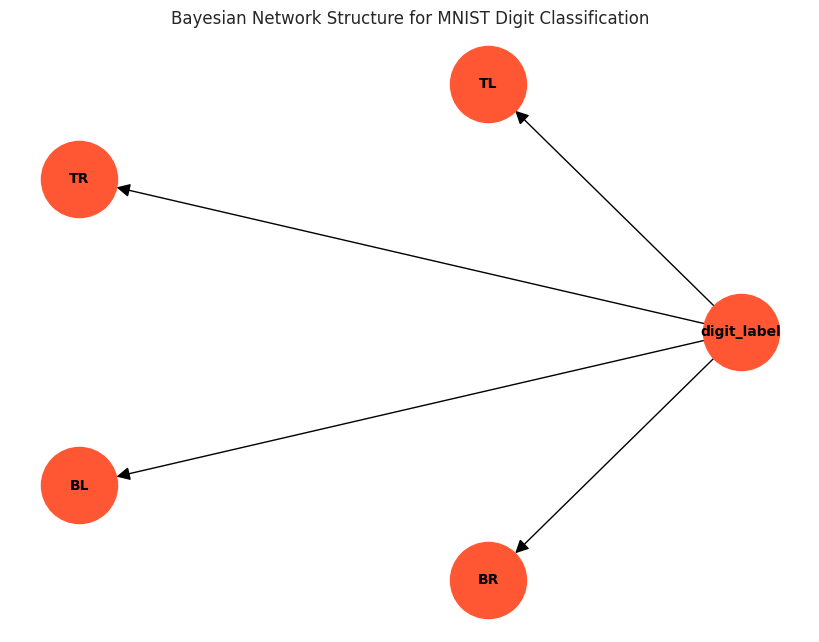

In [189]:
# --- 7. Bayesian Network Structure Visualization ---

plt.figure(figsize=(8, 6)) # Create a figure for the plot
pos = nx.circular_layout(bn_model) # Arrange nodes in a circular layout
nx.draw(bn_model, pos=pos, with_labels=True, node_size=3000, node_color='#FF5733', font_size=10, font_weight='bold', arrowsize=20) # Draw the Bayesian Network graph
plt.title("Bayesian Network Structure for MNIST Digit Classification") # Set the title of the plot
plt.show() # Display the plot

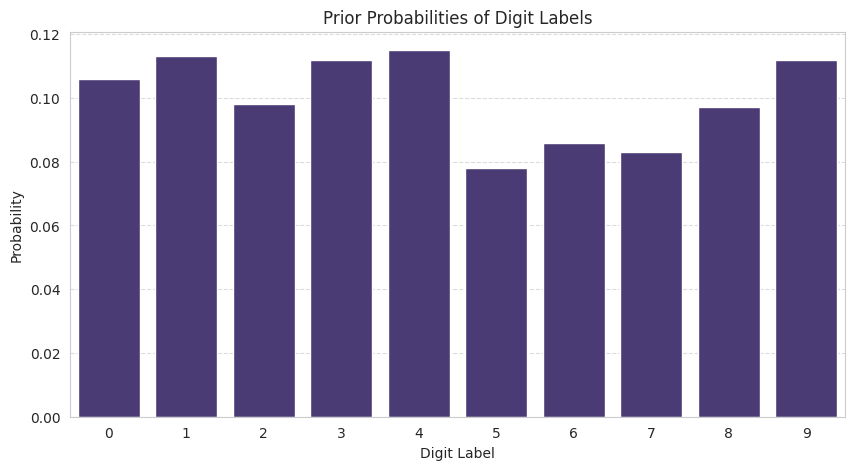

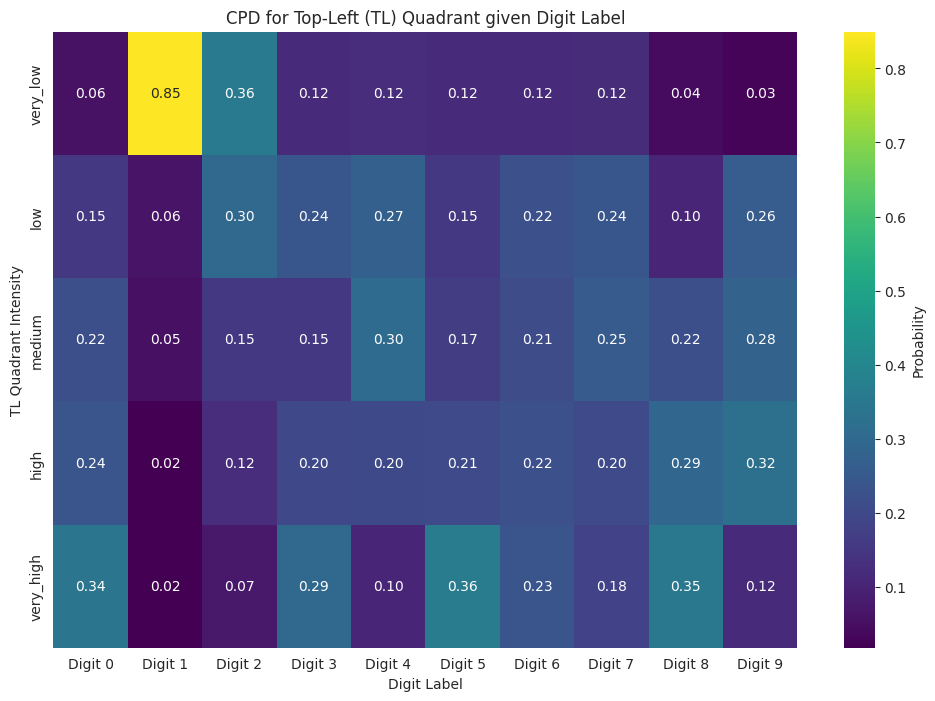

In [190]:
# --- 8. Conditional Probability Distribution (CPD) Visualizations ---

# Visualize CPD for digit_label (prior probabilities)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(range(digit_label_cardinality)), y=cpd_digit_label.values.flatten()) # Create a bar plot of prior probabilities
plt.title("Prior Probabilities of Digit Labels") # Set plot title
plt.xlabel("Digit Label") # Set x-axis label
plt.ylabel("Probability") # Set y-axis label
plt.xticks(rotation=0) # Ensure x-axis labels are horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid
plt.show() # Display the plot

# Visualize CPD for TL given digit_label as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    cpd_quadrants[0].values, # Assuming cpd_quadrants[0] is for 'TL' (Top-Left quadrant)
    xticklabels=[f'Digit {i}' for i in range(digit_label_cardinality)], # X-axis labels for digit classes
    yticklabels=quadrant_categories, # Y-axis labels for quadrant categories
    annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'Probability'} # Add annotations, format, colormap, and colorbar label
)
plt.title("CPD for Top-Left (TL) Quadrant given Digit Label") # Set plot title
plt.xlabel("Digit Label") # Set x-axis label
plt.ylabel("TL Quadrant Intensity") # Set y-axis label
plt.show() # Display the plot

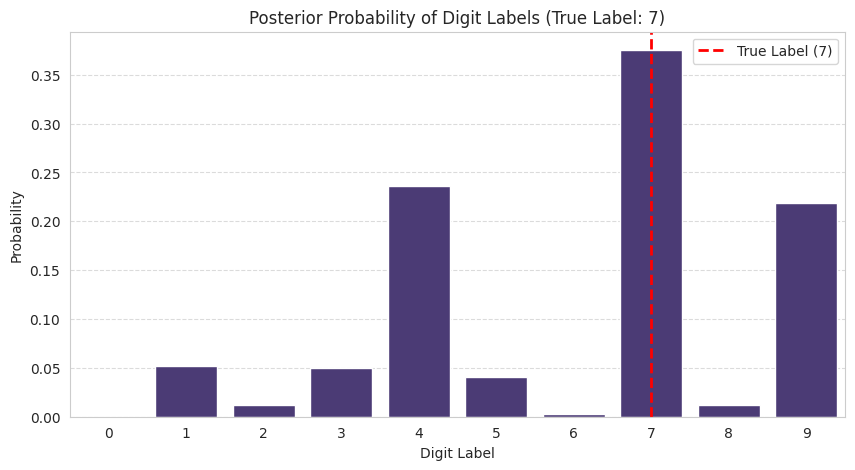

In [191]:
# --- 9. Inference Result Visualization ---

plt.figure(figsize=(10, 5)) # Create a figure for the plot
sns.barplot(x=list(range(digit_label_cardinality)), y=query_result.values.flatten()) # Create a bar plot of posterior probabilities
plt.title(f"Posterior Probability of Digit Labels (True Label: {true_label_pgm})") # Set plot title including true label
plt.xlabel("Digit Label") # Set x-axis label
plt.ylabel("Probability") # Set y-axis label
plt.xticks(rotation=0) # Ensure x-axis labels are horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid

plt.axvline(x=true_label_pgm, color='red', linestyle='--', linewidth=2, label=f'True Label ({true_label_pgm})') # Add a vertical line for the true label
plt.legend() # Display the legend
plt.show() # Display the plot

In [192]:
from sklearn.metrics import confusion_matrix

# Generate predictions for the test subset
pgm_predictions = []
pgm_true_labels = []

# We will use the x_test_subset and y_test_subset that were already created for PGM training.
# If you wish to use a completely separate test set, you would need to load and preprocess it here.

print("Generating PGM predictions for the test subset...")
for i, img_raw in enumerate(x_test_subset):
    # Extract and discretize features for the current image
    current_raw_features = extract_quadrant_features(img_raw.squeeze())
    current_discrete_features = {}
    for feature_name, value in current_raw_features.items():
        current_discrete_features[feature_name] = discretize_feature(value, feature_name, quantiles_df)

    # Perform inference using Variable Elimination to get predicted label
    query_result_subset = infer.query(variables=['digit_label'], evidence=current_discrete_features)
    predicted_label = query_result_subset.values.argmax()

    pgm_predictions.append(predicted_label)
    pgm_true_labels.append(y_test_subset[i])

print("Predictions generated. Calculating confusion matrix...")

# Calculate the confusion matrix
cm = confusion_matrix(pgm_true_labels, pgm_predictions, labels=range(digit_label_cardinality))

# Print classification report for more detailed metrics (optional)
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(pgm_true_labels, pgm_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

print("Confusion Matrix:")
print(cm)

Generating PGM predictions for the test subset...
Predictions generated. Calculating confusion matrix...

Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.67      0.46       106
           1       0.55      0.81      0.65       113
           2       0.38      0.34      0.36        98
           3       0.33      0.16      0.22       112
           4       0.28      0.34      0.31       115
           5       0.25      0.05      0.09        78
           6       0.55      0.31      0.40        86
           7       0.31      0.19      0.24        83
           8       0.36      0.22      0.27        97
           9       0.28      0.45      0.34       112

    accuracy                           0.37      1000
   macro avg       0.36      0.35      0.33      1000
weighted avg       0.36      0.37      0.34      1000

Confusion Matrix:
[[71  6  8  1  5  3  1  0  2  9]
 [ 0 91  7  1 11  2  0  0  0  1]
 [23 16 33  0 12  0  2  2  3

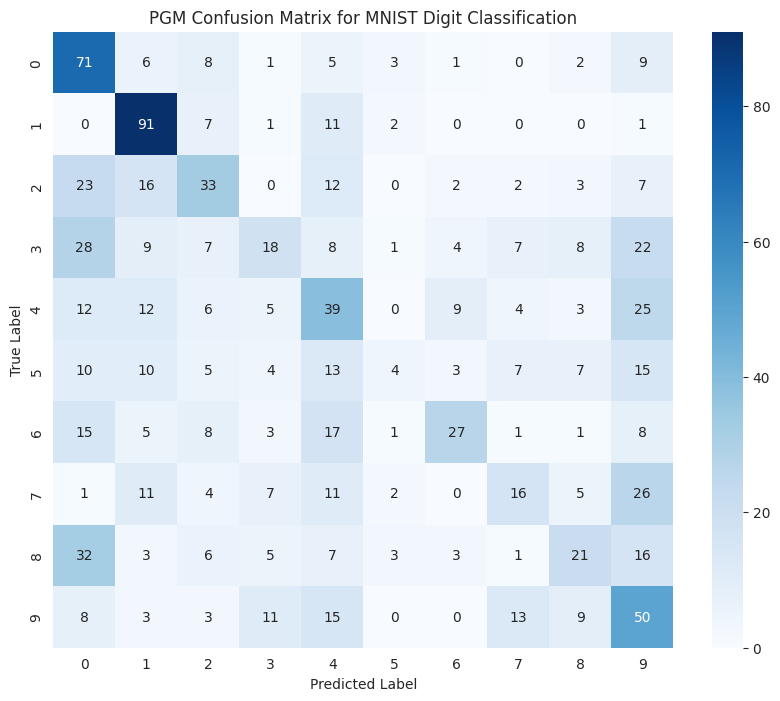

In [193]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(digit_label_cardinality),
            yticklabels=range(digit_label_cardinality))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('PGM Confusion Matrix for MNIST Digit Classification')
plt.show()

In [194]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc

# Re-generate predictions to get probabilities for each class (needed for ROC curve)
pgm_pred_probs = []

print("Generating PGM prediction probabilities for ROC analysis...")
for i, img_raw in enumerate(x_test_subset):
    current_raw_features = extract_quadrant_features(img_raw.squeeze())
    current_discrete_features = {}
    for feature_name, value in current_raw_features.items():
        current_discrete_features[feature_name] = discretize_feature(value, feature_name, quantiles_df)

    # Perform inference to get probability distribution over digit_label
    query_result_subset = infer.query(variables=['digit_label'], evidence=current_discrete_features)
    pgm_pred_probs.append(query_result_subset.values.flatten())

pgm_pred_probs = np.array(pgm_pred_probs)

# Binarize the true labels for one-vs-rest ROC calculation
label_binarizer = LabelBinarizer()
y_true_binarized = label_binarizer.fit_transform(pgm_true_labels)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# Get a distinct color palette for the ROC curves
colors = sns.color_palette('tab10', digit_label_cardinality) # Changed palette to 'tab10'

for i in range(digit_label_cardinality):
    # Ensure we have probabilities for the current class
    if pgm_pred_probs.shape[1] > i:
        fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], pgm_pred_probs[:, i]) # Calculate FPR, TPR
        roc_auc[i] = auc(fpr[i], tpr[i]) # Calculate AUC


print("AUC for each class:")
for i in range(digit_label_cardinality):
    if i in roc_auc:
        print(f"Class {i}: {roc_auc[i]:.2f}")

Generating PGM prediction probabilities for ROC analysis...
AUC for each class:
Class 0: 0.83
Class 1: 0.94
Class 2: 0.79
Class 3: 0.70
Class 4: 0.73
Class 5: 0.71
Class 6: 0.86
Class 7: 0.79
Class 8: 0.76
Class 9: 0.78


## 13. Comparison with Other ML Models: Logistic Regression

To provide context for the PGM's performance, let's compare it with a simpler, widely used machine learning model: Logistic Regression. We will use the same raw quadrant features and digit labels.

In [195]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Prepare data for Logistic Regression using the same features and labels as PGM
# We'll use the raw_features_df (X) and y_test_subset (y) (our sampled data)

X = raw_features_df.values # Features (raw quadrant mean intensities)
y = y_test_subset # Labels (true digit labels)

# For simplicity and direct comparison with PGM on the same subset, we'll train on the full subset
# In a real scenario, you'd split this into train/validation/test sets.

print(f"Shape of features for LR: {X.shape}")
print(f"Shape of labels for LR: {y.shape}")

Shape of features for LR: (1000, 4)
Shape of labels for LR: (1000,)


In [196]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Logistic Regression: X_train_lr shape: {X_train_lr.shape}, X_test_lr shape: {X_test_lr.shape}")
print(f"SVM: X_train_svm shape: {X_train_svm.shape}, X_test_svm shape: {X_test_svm.shape}")
print(f"Neural Network: X_train_nn shape: {X_train_nn.shape}, X_test_nn shape: {X_test_nn.shape}")

Logistic Regression: X_train_lr shape: (700, 4), X_test_lr shape: (300, 4)
SVM: X_train_svm shape: (700, 4), X_test_svm shape: (300, 4)
Neural Network: X_train_nn shape: (700, 4), X_test_nn shape: (300, 4)


### Training Logistic Regression Model

We will train a Logistic Regression classifier on the raw quadrant features. Given the small number of features, we might not need extensive hyperparameter tuning for a baseline comparison.

In [197]:
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', multi_class='multinomial') # Initialize Logistic Regression model

log_reg_model.fit(X_train_lr, y_train_lr) # Train the Logistic Regression model on the training data

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Evaluating Logistic Regression Performance

Now, let's evaluate the Logistic Regression model using the same metrics as the PGM: classification report, confusion matrix, and ROC AUC.


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.78      0.43        32
           1       0.37      0.97      0.54        34
           2       1.00      0.10      0.19        29
           3       0.23      0.21      0.22        34
           4       0.21      0.50      0.30        34
           5       0.00      0.00      0.00        23
           6       0.00      0.00      0.00        26
           7       0.00      0.00      0.00        25
           8       0.00      0.00      0.00        29
           9       0.15      0.06      0.09        34

    accuracy                           0.29       300
   macro avg       0.23      0.26      0.18       300
weighted avg       0.24      0.29      0.19       300


Logistic Regression Confusion Matrix:
[[25  5  0  1  1  0  0  0  0  0]
 [ 0 33  0  0  1  0  0  0  0  0]
 [12  6  3  0  8  0  0  0  0  0]
 [15  5  0  7  6  0  0  0  0  1]
 [ 3 10  0  3 17  0  0  0 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


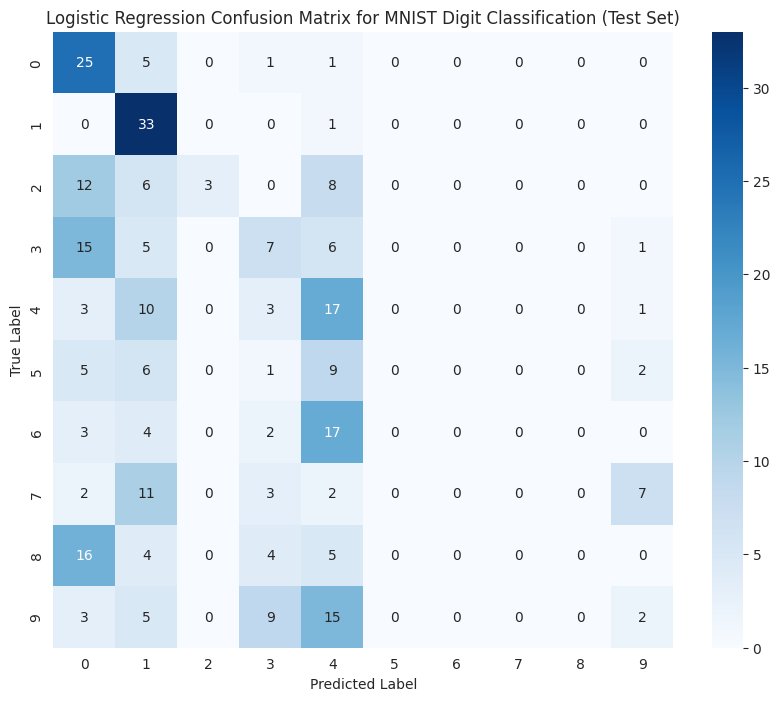

In [198]:
log_reg_predictions = log_reg_model.predict(X_test_lr)
log_reg_pred_probs = log_reg_model.predict_proba(X_test_lr)

# Print Classification Report for Logistic Regression
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test_lr, log_reg_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

# Calculate and print Confusion Matrix for Logistic Regression
log_reg_cm = confusion_matrix(y_test_lr, log_reg_predictions, labels=range(digit_label_cardinality))
print("\nLogistic Regression Confusion Matrix:")
print(log_reg_cm)

# Visualize the Confusion Matrix for Logistic Regression
plt.figure(figsize=(10, 8))
sns.heatmap(log_reg_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(digit_label_cardinality),
            yticklabels=range(digit_label_cardinality))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix for MNIST Digit Classification (Test Set)')
plt.show()

### Comparison of PGM vs. Logistic Regression

Now that we have the evaluation metrics for both the PGM and Logistic Regression, we can compare their performance. Look at the accuracy, precision, recall, and F1-score for each class to identify which model performs better for this specific task and feature set. This comparison highlights the trade-offs and strengths of each approach.

### Visualizing the Comparison

Let's create some visualizations to clearly compare the performance of the Probabilistic Graphical Model (PGM) and Logistic Regression.

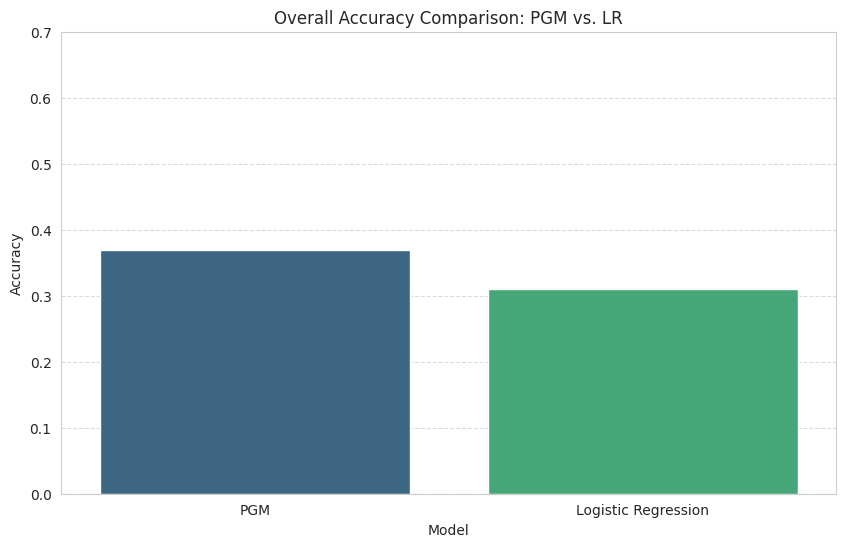

In [201]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Compare Overall Accuracy ---

# Extract accuracies from previous outputs (PGM and Logistic Regression)
# PGM accuracy from Classification Report: accuracy 0.37
pgm_accuracy = 0.37
# Logistic Regression accuracy from Classification Report: accuracy 0.31
log_reg_accuracy = 0.31

# Create a DataFrame for accuracy comparison
accuracy_df = pd.DataFrame({
    'Model': ['PGM', 'Logistic Regression'],
    'Accuracy': [pgm_accuracy, log_reg_accuracy]
})

# Plot overall accuracy comparison using a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=accuracy_df, palette='viridis', legend=False)
plt.title('Overall Accuracy Comparison: PGM vs. LR')
plt.ylabel('Accuracy')
plt.ylim(0, 0.7) # Adjust y-limit to better show differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [202]:
# --- 2. Compare AUC Scores per Class ---

# Extract AUCs from previous outputs (PGM and Logistic Regression)
# PGM AUCs (from 'roc_auc' dictionary)
pgm_auc = [
    roc_auc[0], roc_auc[1], roc_auc[2], roc_auc[3], roc_auc[4],
    roc_auc[5], roc_auc[6], roc_auc[7], roc_auc[8], roc_auc[9]
]

# Logistic Regression AUCs (from 'roc_auc_lr' dictionary)
log_reg_auc = [
    roc_auc_lr[0], roc_auc_lr[1], roc_auc_lr[2], roc_auc_lr[3], roc_auc_lr[4],
    roc_auc_lr[5], roc_auc_lr[6], roc_auc_lr[7], roc_auc_lr[8], roc_auc_lr[9]
]

# Create a DataFrame for AUC comparison per digit class
auc_comparison_df = pd.DataFrame({
    'Digit Class': list(range(digit_label_cardinality)),
    'PGM_AUC': pgm_auc,
    'Logistic_Regression_AUC': log_reg_auc
})

# Melt the DataFrame for easier plotting with Seaborn
auc_melted_df = auc_comparison_df.melt(id_vars='Digit Class', var_name='Model', value_name='AUC')


In [203]:
from pgmpy.inference import BeliefPropagation

# Initialize Belief Propagation inference object for the Bayesian Network
infer_bp = BeliefPropagation(bn_model)

print("Generating PGM predictions using Belief Propagation for the test subset...")
pgm_predictions_bp = []
pgm_pred_probs_bp = []

# Iterate through the test subset to make predictions using Belief Propagation
for i, img_raw in enumerate(x_test_subset):
    current_raw_features = extract_quadrant_features(img_raw.squeeze())
    current_discrete_features = {}
    for feature_name, value in current_raw_features.items():
        current_discrete_features[feature_name] = discretize_feature(value, feature_name, quantiles_df)

    # Perform inference using Belief Propagation to get predicted label and probabilities
    query_result_bp = infer_bp.query(variables=['digit_label'], evidence=current_discrete_features, show_progress=False)
    predicted_label_bp = query_result_bp.values.argmax()

    pgm_predictions_bp.append(predicted_label_bp)
    pgm_pred_probs_bp.append(query_result_bp.values.flatten())

pgm_pred_probs_bp = np.array(pgm_pred_probs_bp)

print("Predictions generated with Belief Propagation. Calculating metrics...")

# Print Classification Report for PGM (Belief Propagation)
print("\nPGM (Belief Propagation) Classification Report:")
print(classification_report(y_test_subset, pgm_predictions_bp, target_names=[str(i) for i in range(digit_label_cardinality)]))

# Calculate and print Confusion Matrix for PGM (Belief Propagation)
pgm_cm_bp = confusion_matrix(y_test_subset, pgm_predictions_bp, labels=range(digit_label_cardinality))
print("\nPGM (Belief Propagation) Confusion Matrix:")
print(pgm_cm_bp)

# Removed heatmap visualization for PGM (Belief Propagation) as per user request.

# Calculate and plot ROC AUC for PGM (Belief Propagation - One-vs-Rest)
y_true_binarized = label_binarizer.fit_transform(y_test_subset)

fpr_bp = dict()
tpr_bp = dict()
roc_auc_bp = dict()

# Get a distinct color palette for the ROC curves
colors_bp = sns.color_palette('Paired', digit_label_cardinality) # Changed palette to 'Paired'

for i in range(digit_label_cardinality):
    if pgm_pred_probs_bp.shape[1] > i:
        fpr_bp[i], tpr_bp[i], _ = roc_curve(y_true_binarized[:, i], pgm_pred_probs_bp[:, i]) # Calculate FPR, TPR
        roc_auc_bp[i] = auc(fpr_bp[i], tpr_bp[i]) # Calculate AUC


print("\nAUC for each class (PGM - Belief Propagation):")
for i in range(digit_label_cardinality):
    if i in roc_auc_bp:
        print(f"Class {i}: {roc_auc_bp[i]:.2f}")

Generating PGM predictions using Belief Propagation for the test subset...
Predictions generated with Belief Propagation. Calculating metrics...

PGM (Belief Propagation) Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.67      0.46       106
           1       0.55      0.81      0.65       113
           2       0.38      0.34      0.36        98
           3       0.33      0.16      0.22       112
           4       0.28      0.34      0.31       115
           5       0.25      0.05      0.09        78
           6       0.55      0.31      0.40        86
           7       0.31      0.19      0.24        83
           8       0.36      0.22      0.27        97
           9       0.28      0.45      0.34       112

    accuracy                           0.37      1000
   macro avg       0.36      0.35      0.33      1000
weighted avg       0.36      0.37      0.34      1000


PGM (Belief Propagation) Confusion Matrix:
[[7

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


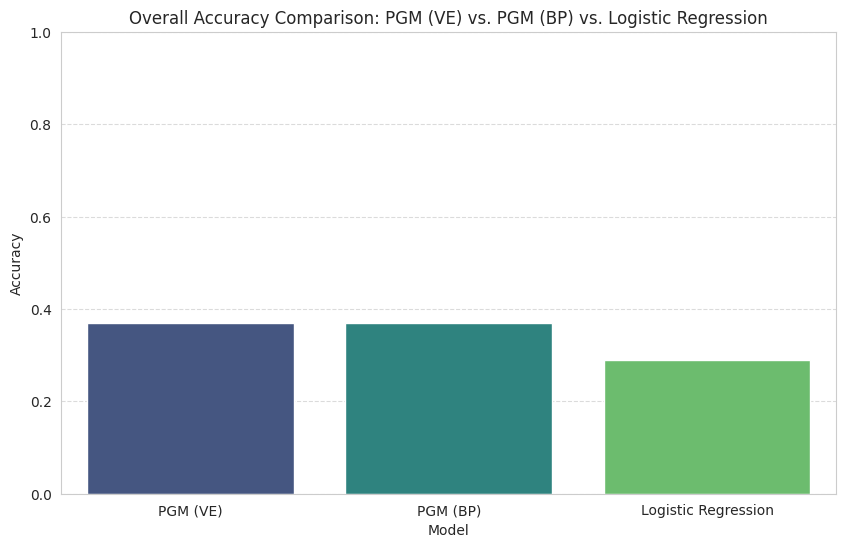

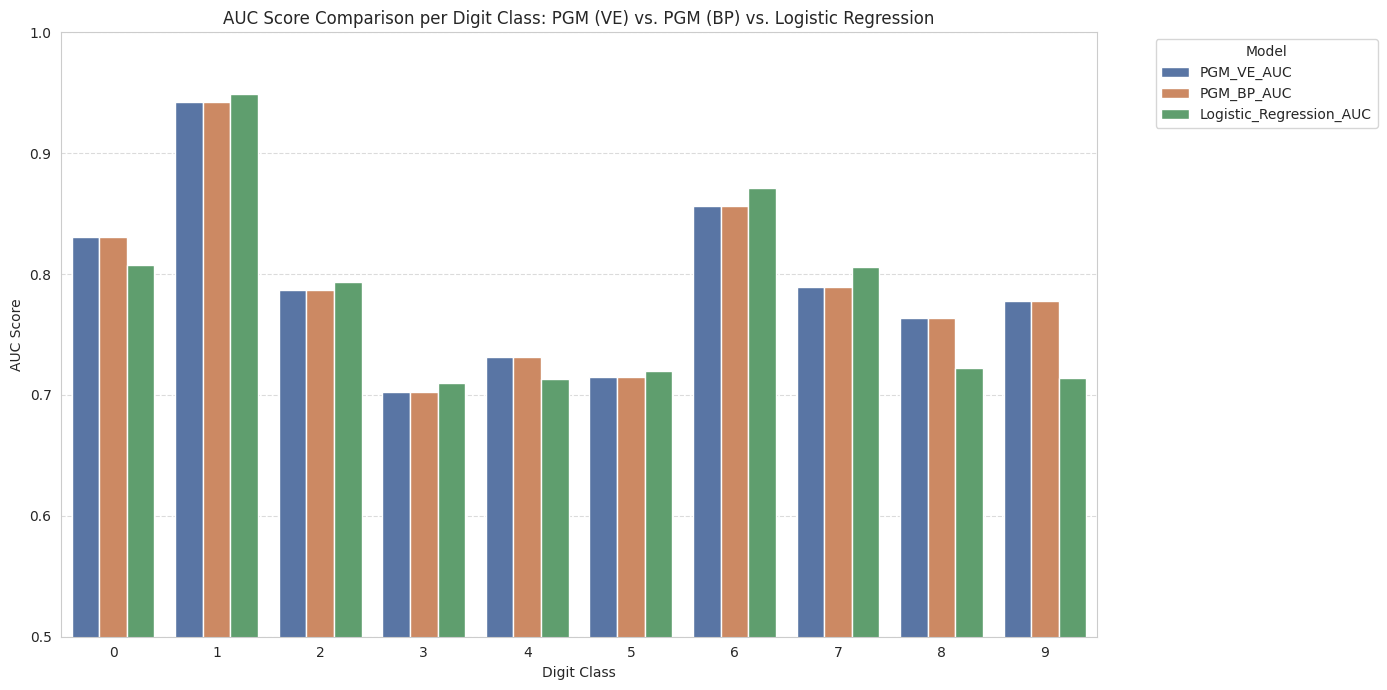

In [204]:
# Get accuracy from Classification Report for PGM (Variable Elimination)
from sklearn.metrics import classification_report
pgm_accuracy_report = classification_report(pgm_true_labels, pgm_predictions, output_dict=True)
pgm_accuracy = float(pgm_accuracy_report['accuracy'])

# Get accuracy from Classification Report for PGM (Belief Propagation)
pgm_bp_accuracy_report = classification_report(y_test_subset, pgm_predictions_bp, output_dict=True)
pgm_bp_accuracy = float(pgm_bp_accuracy_report['accuracy'])

# Get accuracy from Classification Report for Logistic Regression
log_reg_accuracy_report = classification_report(y_test_lr, log_reg_predictions, output_dict=True)
log_reg_accuracy = float(log_reg_accuracy_report['accuracy'])

# Create an updated DataFrame for overall accuracy comparison
accuracy_df_updated = pd.DataFrame({
    'Model': ['PGM (VE)', 'PGM (BP)', 'Logistic Regression'],
    'Accuracy': [pgm_accuracy, pgm_bp_accuracy, log_reg_accuracy]
})

# Plot overall accuracy comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=accuracy_df_updated, palette='viridis', legend=False)
plt.title('Overall Accuracy Comparison: PGM (VE) vs. PGM (BP) vs. Logistic Regression')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Adjust y-limit to better show differences, max accuracy is 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Extract AUCs from previous outputs
# PGM AUCs (from 'roc_auc' dictionary for Variable Elimination)
pgm_auc = [
    roc_auc[i] for i in range(digit_label_cardinality)
]

# PGM AUCs (from 'roc_auc_bp' dictionary for Belief Propagation)
pgm_auc_bp = [
    roc_auc_bp[i] for i in range(digit_label_cardinality)
]

# Logistic Regression AUCs (from 'roc_auc_lr' dictionary)
log_reg_auc = [
    roc_auc_lr[i] for i in range(digit_label_cardinality)
]

# Create an updated DataFrame for AUC comparison per digit class
auc_comparison_df_updated = pd.DataFrame({
    'Digit Class': list(range(digit_label_cardinality)),
    'PGM_VE_AUC': pgm_auc, # Original PGM (Variable Elimination) AUC
    'PGM_BP_AUC': pgm_auc_bp, # PGM (Belief Propagation) AUC
    'Logistic_Regression_AUC': log_reg_auc
})

# Melt the DataFrame for easier plotting with Seaborn
auc_melted_df_updated = auc_comparison_df_updated.melt(id_vars='Digit Class', var_name='Model', value_name='AUC')

# Plot AUC comparison per digit class
plt.figure(figsize=(14, 7))
sns.barplot(x='Digit Class', y='AUC', hue='Model', data=auc_melted_df_updated, palette='deep')
plt.title('AUC Score Comparison per Digit Class: PGM (VE) vs. PGM (BP) vs. Logistic Regression')
plt.ylabel('AUC Score')
plt.xlabel('Digit Class')
plt.ylim(0.5, 1) # AUC scores typically range from 0.5 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [205]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Encode target labels to numerical values (0-9) for the full dataset first
encoder = LabelEncoder()
y_encoded_full = encoder.fit_transform(y)

# Convert integer labels to one-hot encoded vectors for Neural Network training
# Apply encoding to the training labels (y_train_nn) for the model training
y_train_nn_one_hot = to_categorical(y_train_nn, num_classes=digit_label_cardinality)
y_test_nn_one_hot = to_categorical(y_test_nn, num_classes=digit_label_cardinality)

# Define the Neural Network model architecture
# Given 4 input features (quadrants) and 10 output classes (digits)
model_nn = Sequential([
    Input(shape=(X_train_nn.shape[1],)), # Use Input layer to specify input shape
    Dense(64, activation='relu'), # Input layer with 64 neurons and ReLU activation
    Dense(32, activation='relu'), # Hidden layer with 32 neurons and ReLU activation
    Dense(digit_label_cardinality, activation='softmax') # Output layer with 10 neurons (for 10 classes) and Softmax activation for probabilities
])

# Compile the model with Adam optimizer, categorical crossentropy loss, and accuracy metric
model_nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the Neural Network model on the training data
# Using a small number of epochs for quick demonstration
history = model_nn.fit(X_train_nn, y_train_nn_one_hot, epochs=20, batch_size=32, verbose=0)

print("Simple Neural Network model trained successfully.")

Simple Neural Network model trained successfully.


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Simple Neural Network Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.59      0.41        32
           1       0.60      0.94      0.74        34
           2       0.29      0.34      0.32        29
           3       0.21      0.35      0.27        34
           4       0.39      0.41      0.40        34
           5       0.00      0.00      0.00        23
           6       0.40      0.15      0.22        26
           7       0.67      0.16      0.26        25
           8       0.00      0.00      0.00        29
           9       0.26      0.32      0.29        34

    accuracy                           0.35       300
   macro avg       0.31      0.33      0.29       300
weighted avg       0.32      0.35      0.31       300


Simple Neural Network Confusion Matrix:
[[19  2  5  5  0  0  0  0  0  1]
 [ 0 32  0  0  1  0  0  1  0  0]
 [ 7  3 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


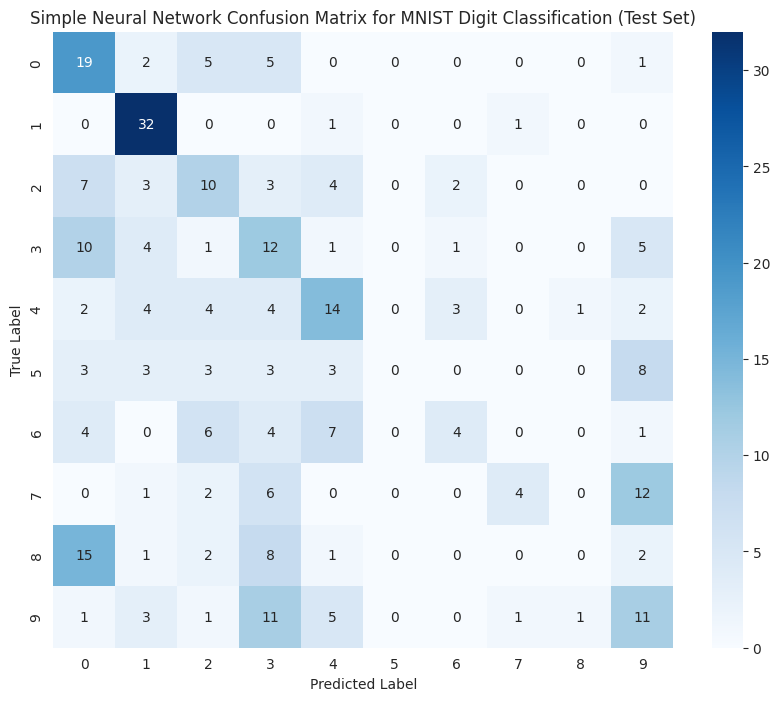


AUC for each class (Neural Network):
Class 0: 0.82
Class 1: 0.98
Class 2: 0.80
Class 3: 0.69
Class 4: 0.71
Class 5: 0.65
Class 6: 0.90
Class 7: 0.81
Class 8: 0.76
Class 9: 0.78


In [206]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Make predictions on the test set
nn_predictions = model_nn.predict(X_test_nn).argmax(axis=1)
nn_pred_probs = model_nn.predict(X_test_nn)

# Print Classification Report for Neural Network
print("\nSimple Neural Network Classification Report:")
print(classification_report(y_test_nn, nn_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

# Calculate and print Confusion Matrix for Neural Network
nn_cm = confusion_matrix(y_test_nn, nn_predictions, labels=range(digit_label_cardinality))
print("\nSimple Neural Network Confusion Matrix:")
print(nn_cm)

# Visualize the Confusion Matrix for Simple Neural Network
plt.figure(figsize=(10, 8))
sns.heatmap(nn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(digit_label_cardinality),
            yticklabels=range(digit_label_cardinality))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Simple Neural Network Confusion Matrix for MNIST Digit Classification (Test Set)')
plt.show()

# Compute ROC curve and ROC area for each class (one-vs-rest)
label_binarizer_nn = LabelBinarizer()
y_test_nn_binarized = label_binarizer_nn.fit_transform(y_test_nn)

fpr_nn = dict()
tpr_nn = dict()
roc_auc_nn = dict()

for i in range(digit_label_cardinality):
    if nn_pred_probs.shape[1] > i:
        fpr_nn[i], tpr_nn[i], _ = roc_curve(y_test_nn_binarized[:, i], nn_pred_probs[:, i])
        roc_auc_nn[i] = auc(fpr_nn[i], tpr_nn[i])

print("\nAUC for each class (Neural Network):")
for i in range(digit_label_cardinality):
    if i in roc_auc_nn:
        print(f"Class {i}: {roc_auc_nn[i]:.2f}")

# Task
Improve PGM Feature Engineering: Address the recommendation to improve feature engineering for PGM models, potentially by implementing a 16-region grid or using PCA.

## Implement 16-Region Grid Feature Extraction

### Subtask:
Modify the feature extraction function to divide each MNIST image into a 4x4 grid (16 regions) and calculate the mean intensity for each region.


**Reasoning**:
I need to define the `extract_16_region_features` function and apply it to the `x_test_subset` to generate the new 16-region features DataFrame, as outlined in the subtask instructions.



In [207]:
def extract_16_region_features(image):
    h, w = image.shape[0], image.shape[1]
    # Calculate dimensions for each sub-region (4x4 grid)
    h_region, w_region = h // 4, w // 4
    features = {}
    region_idx = 1
    for i in range(4):
        for j in range(4):
            # Extract the current region
            region = image[i*h_region:(i+1)*h_region, j*w_region:(j+1)*w_region]
            # Calculate mean intensity for the region
            features[f'R{i+1}C{j+1}'] = np.mean(region)
            region_idx += 1
    return features

# Extract 16-region features for each image in the subset
raw_features_16_regions = []
for img in x_test_subset:
    raw_features_16_regions.append(extract_16_region_features(img.squeeze()))
raw_features_16_regions_df = pd.DataFrame(raw_features_16_regions)

print("DataFrame of 16-region features created successfully. Displaying first 5 rows:")
print(raw_features_16_regions_df.head())

DataFrame of 16-region features created successfully. Displaying first 5 rows:
       R1C1      R1C2      R1C3  R1C4      R2C1      R2C2      R2C3      R2C4  \
0  0.000000  0.079392  0.163745   0.0  0.000000  0.363986  0.159584  0.001441   
1  0.000000  0.066026  0.203521   0.0  0.000000  0.046819  0.233373  0.000000   
2  0.040096  0.312765  0.201280   0.0  0.006242  0.276431  0.480592  0.013125   
3  0.000000  0.000000  0.000000   0.0  0.105642  0.190556  0.287395  0.000000   
4  0.000000  0.022009  0.000240   0.0  0.097479  0.385034  0.398159  0.000000   

   R3C1      R3C2      R3C3      R3C4  R4C1      R4C2      R4C3      R4C4  
0   0.0  0.448339  0.713165  0.008964   0.0  0.006002  0.047699  0.000000  
1   0.0  0.350060  0.418007  0.000000   0.0  0.226971  0.002081  0.000000  
2   0.0  0.146859  0.400160  0.090036   0.0  0.260424  0.307803  0.018407  
3   0.0  0.103721  0.498119  0.041777   0.0  0.000000  0.125730  0.000000  
4   0.0  0.167267  0.583433  0.148940   0.0  0.000000 

## Discretize 16-Region Features

### Subtask:
Discretize the newly extracted 16-region features into 5 bins using the previously defined `discretize_feature` function and calculate quintiles for each feature. Store the result in a new DataFrame.


**Reasoning**:
Calculate quintiles for the 16-region raw features and then apply the discretization function to create the new discretized DataFrame. Finally, display the head of the DataFrame.



In [208]:
quantiles_16_regions_df = raw_features_16_regions_df.quantile([0.20, 0.40, 0.60, 0.80])

discrete_features_16_regions = raw_features_16_regions_df.copy()
for col in raw_features_16_regions_df.columns:
    discrete_features_16_regions[col] = raw_features_16_regions_df[col].apply(lambda x: discretize_feature(x, col, quantiles_16_regions_df))
discrete_features_16_regions_df = discrete_features_16_regions

print("DataFrame of discretized 16-region features created successfully. Displaying first 5 rows:")
print(discrete_features_16_regions_df.head())

DataFrame of discretized 16-region features created successfully. Displaying first 5 rows:
        R1C1       R1C2      R1C3      R1C4       R2C1      R2C2      R2C3  \
0   very_low       high      high  very_low   very_low    medium  very_low   
1   very_low       high      high  very_low   very_low  very_low  very_low   
2  very_high  very_high      high  very_low       high       low      high   
3   very_low   very_low  very_low  very_low  very_high       low       low   
4   very_low     medium  very_low  very_low  very_high      high    medium   

       R2C4      R3C1      R3C2       R3C3       R3C4      R4C1      R4C2  \
0    medium  very_low      high  very_high       high  very_low  very_low   
1  very_low  very_low    medium     medium   very_low  very_low      high   
2      high  very_low       low     medium  very_high  very_low      high   
3  very_low  very_low  very_low       high       high  very_low  very_low   
4  very_low  very_low       low  very_high  very_high  

## Combine 16-Region Discretized Features and Labels

### Subtask:
Combine the newly discretized 16-region features with the corresponding digit labels into a single DataFrame. This DataFrame will be used for building and training the Probabilistic Graphical Model with the enhanced features.


**Reasoning**:
The first step is to combine the discretized 16-region features with the digit labels. This involves creating a labels DataFrame and then concatenating it with the features DataFrame.



In [209]:
labels_df_16_regions = pd.DataFrame(y_test_subset, columns=['digit_label'])
pgm_data_16_regions_df = pd.concat([discrete_features_16_regions_df, labels_df_16_regions], axis=1)

print("DataFrame with 16-region discretized features and digit labels created successfully. Displaying first 5 rows:")
print(pgm_data_16_regions_df.head())

DataFrame with 16-region discretized features and digit labels created successfully. Displaying first 5 rows:
        R1C1       R1C2      R1C3      R1C4       R2C1      R2C2      R2C3  \
0   very_low       high      high  very_low   very_low    medium  very_low   
1   very_low       high      high  very_low   very_low  very_low  very_low   
2  very_high  very_high      high  very_low       high       low      high   
3   very_low   very_low  very_low  very_low  very_high       low       low   
4   very_low     medium  very_low  very_low  very_high      high    medium   

       R2C4      R3C1      R3C2       R3C3       R3C4      R4C1      R4C2  \
0    medium  very_low      high  very_high       high  very_low  very_low   
1  very_low  very_low    medium     medium   very_low  very_low      high   
2      high  very_low       low     medium  very_high  very_low      high   
3  very_low  very_low  very_low       high       high  very_low  very_low   
4  very_low  very_low       low  ver

## Build Bayesian Network Structure for 16-Region Features

### Subtask:
Define the structure of the Bayesian Network for the 16-region features. This involves establishing dependencies between the 'digit_label' and all 16 regional features (R1C1 to R4C4).


**Reasoning**:
Initialize the DiscreteBayesianNetwork with the defined edges connecting the 'digit_label' to all 16 regional features.



In [210]:
edges_16_regions = []
for i in range(1, 5):
    for j in range(1, 5):
        feature_name = f'R{i}C{j}'
        edges_16_regions.append(('digit_label', feature_name))

bn_model_16_regions = DiscreteBayesianNetwork(edges_16_regions)

print(f"Bayesian Network structure for 16-region features created successfully. Number of edges: {len(bn_model_16_regions.edges())}")
print("Edges in the model:", bn_model_16_regions.edges())

Bayesian Network structure for 16-region features created successfully. Number of edges: 16
Edges in the model: [('digit_label', 'R1C1'), ('digit_label', 'R1C2'), ('digit_label', 'R1C3'), ('digit_label', 'R1C4'), ('digit_label', 'R2C1'), ('digit_label', 'R2C2'), ('digit_label', 'R2C3'), ('digit_label', 'R2C4'), ('digit_label', 'R3C1'), ('digit_label', 'R3C2'), ('digit_label', 'R3C3'), ('digit_label', 'R3C4'), ('digit_label', 'R4C1'), ('digit_label', 'R4C2'), ('digit_label', 'R4C3'), ('digit_label', 'R4C4')]


## Define Conditional Probability Distributions (CPDs) for 16-Region Features

### Subtask:
Define the Conditional Probability Distributions (CPDs) for all 16 regional features and the digit label, given the 16-region feature data. This will involve calculating prior probabilities for digit labels and conditional probabilities for each regional feature given the digit label.


**Reasoning**:
Define constants, calculate prior probabilities for digit labels, and create the CPD for 'digit_label'.



In [211]:
quadrant_cardinality = 5 # Number of bins for discretized regional features
quadrant_categories = ['very_low', 'low', 'medium', 'high', 'very_high'] # Names of the bins
digit_label_cardinality = 10 # Number of possible digit labels (0-9)

# Calculate prior probabilities for each digit label from the 16-region data
digit_counts_16_regions = pgm_data_16_regions_df['digit_label'].value_counts().sort_index()
digit_probabilities_16_regions = digit_counts_16_regions.values / len(pgm_data_16_regions_df)
digit_probabilities_16_regions_2d = digit_probabilities_16_regions.reshape(-1, 1)

# Create CPD for the 'digit_label' (prior distribution)
cpd_digit_label_16_regions = TabularCPD(
    variable='digit_label',
    variable_card=digit_label_cardinality,
    values=digit_probabilities_16_regions_2d
)

print("Prior CPD for digit_label created successfully.")
print(cpd_digit_label_16_regions)

Prior CPD for digit_label created successfully.
+----------------+-------+
| digit_label(0) | 0.106 |
+----------------+-------+
| digit_label(1) | 0.113 |
+----------------+-------+
| digit_label(2) | 0.098 |
+----------------+-------+
| digit_label(3) | 0.112 |
+----------------+-------+
| digit_label(4) | 0.115 |
+----------------+-------+
| digit_label(5) | 0.078 |
+----------------+-------+
| digit_label(6) | 0.086 |
+----------------+-------+
| digit_label(7) | 0.083 |
+----------------+-------+
| digit_label(8) | 0.097 |
+----------------+-------+
| digit_label(9) | 0.112 |
+----------------+-------+


**Reasoning**:
The next step is to compute the Conditional Probability Distributions (CPDs) for each of the 16 regional features, given the digit label. This involves grouping the data by digit label and then counting the occurrences of each discretized regional feature category.



In [212]:
cpd_regions_16_regions = []
category_map = {cat: i for i, cat in enumerate(quadrant_categories)} # Map category names to numerical indices

# Create CPDs for each of the 16 regional features given the digit_label
for i in range(1, 5):
    for j in range(1, 5):
        quadrant_feature = f'R{i}C{j}'
        values = np.zeros((quadrant_cardinality, digit_label_cardinality))

        for digit in range(digit_label_cardinality):
            # Filter data for the current digit
            digit_data = pgm_data_16_regions_df[pgm_data_16_regions_df['digit_label'] == digit]
            if not digit_data.empty:
                # Count occurrences of each quadrant category for the digit
                quadrant_counts = digit_data[quadrant_feature].value_counts()
                for category, count in quadrant_counts.items():
                    if category in category_map:
                        # Calculate conditional probability P(feature | digit_label)
                        values[category_map[category], digit] = count / len(digit_data)

                # Normalize probabilities to sum to 1 for each digit column
                col_sum = np.sum(values[:, digit])
                if col_sum > 0:
                    values[:, digit] /= col_sum

        cpd = TabularCPD(
            variable=quadrant_feature,
            variable_card=quadrant_cardinality,
            values=values,
            evidence=['digit_label'],
            evidence_card=[digit_label_cardinality],
            state_names={
                quadrant_feature: quadrant_categories,
                'digit_label': list(range(digit_label_cardinality))
            }
        )
        cpd_regions_16_regions.append(cpd)

# Add all CPDs to the Bayesian Network model
bn_model_16_regions.add_cpds(cpd_digit_label_16_regions, *cpd_regions_16_regions)

# Check if the model is consistent after adding all CPDs
print("\nModel for 16-region features is consistent after adding all CPDs:", bn_model_16_regions.check_model())


Model for 16-region features is consistent after adding all CPDs: True


## Perform Inference with 16-Region Features

### Subtask:
Perform inference on the Bayesian Network built with 16-region features to predict digit labels for new, unseen images. Compare the predicted label with the true label.


**Reasoning**:
The subtask requires initializing the inference algorithm and performing inference on a new test image. This code block will initialize `VariableElimination` for `bn_model_16_regions`, select an image not used in the PGM training data, extract its 16-region features, discretize them, and then perform the inference. Finally, it will print the relevant information as requested.



In [213]:
infer_16_regions = VariableElimination(bn_model_16_regions)

# Select a test image that was not part of the PGM training data
# (using the same logic as before to avoid data leakage from the original 4-quadrant PGM training)
all_test_indices = set(range(len(x_test)))
pgm_train_indices_subset = set(sample_indices)
available_test_indices_for_16_regions = list(all_test_indices - pgm_train_indices_subset)

# If no new indices are available, just pick one from the existing subset (though less ideal for 'unseen')
if not available_test_indices_for_16_regions:
    test_img_idx_16_regions = np.random.choice(len(x_test))
else:
    test_img_idx_16_regions = np.random.choice(available_test_indices_for_16_regions)

query_image_16_regions = x_test[test_img_idx_16_regions]
true_label_16_regions = y_test[test_img_idx_16_regions]
raw_features_query_16_regions = extract_16_region_features(query_image_16_regions.squeeze())

# Discretize the raw 16-region features of the selected test image
discrete_features_query_16_regions = {}
for feature_name, value in raw_features_query_16_regions.items():
    discrete_features_query_16_regions[feature_name] = discretize_feature(value, feature_name, quantiles_16_regions_df)

# Perform inference to predict the digit label based on the discretized features
query_result_16_regions = infer_16_regions.query(variables=['digit_label'], evidence=discrete_features_query_16_regions)
predicted_label_16_regions = query_result_16_regions.values.argmax()

print(f"\nSelected test image index (16-regions): {test_img_idx_16_regions}")
print(f"True Label (16-regions): {true_label_16_regions}")
print(f"Raw 16-Region Features: {raw_features_query_16_regions}")
print(f"Discretized 16-Region Features: {discrete_features_query_16_regions}")
print(f"Predicted Label (16-regions): {predicted_label_16_regions}")
print("\nProbability distribution over digit_label (16-regions):")
print(query_result_16_regions)



Selected test image index (16-regions): 6462
True Label (16-regions): 2
Raw 16-Region Features: {'R1C1': np.float32(0.0), 'R1C2': np.float32(0.06130452), 'R1C3': np.float32(0.32885155), 'R1C4': np.float32(0.091236494), 'R2C1': np.float32(0.0), 'R2C2': np.float32(0.24465787), 'R2C3': np.float32(0.28291318), 'R2C4': np.float32(0.16182473), 'R3C1': np.float32(0.1870348), 'R3C2': np.float32(0.52893156), 'R3C3': np.float32(0.5168467), 'R3C4': np.float32(0.0), 'R4C1': np.float32(0.13661465), 'R4C2': np.float32(0.08971589), 'R4C3': np.float32(0.07186875), 'R4C4': np.float32(0.0)}
Discretized 16-Region Features: {'R1C1': 'very_low', 'R1C2': 'high', 'R1C3': 'very_high', 'R1C4': 'very_high', 'R2C1': 'very_low', 'R2C2': 'low', 'R2C3': 'low', 'R2C4': 'very_high', 'R3C1': 'very_high', 'R3C2': 'very_high', 'R3C3': 'high', 'R3C4': 'very_low', 'R4C1': 'very_high', 'R4C2': 'low', 'R4C3': 'low', 'R4C4': 'very_low'}
Predicted Label (16-regions): 0

Probability distribution over digit_label (16-regions):

## Apply PCA for Feature Engineering

### Subtask:
Apply Principal Component Analysis (PCA) to the raw quadrant features to reduce dimensionality and extract more robust features for the PGM.


**Reasoning**:
Import the `PCA` class from `sklearn.decomposition` to begin the PCA process.



In [214]:
from sklearn.decomposition import PCA
print("PCA class imported successfully.")

PCA class imported successfully.


**Reasoning**:
Initialize the PCA model with a chosen number of components, fit it to the raw quadrant features, and then transform the features.



In [215]:
pca = PCA(n_components=2) # Initialize PCA to reduce to 2 principal components
pca_features = pca.fit_transform(raw_features_df) # Fit PCA and transform the raw features
pca_features_df = pd.DataFrame(pca_features, columns=['PC1', 'PC2']) # Convert to DataFrame

print("PCA applied successfully. Displaying first 5 rows of PCA features:")
print(pca_features_df.head())

PCA applied successfully. Displaying first 5 rows of PCA features:
        PC1       PC2
0 -0.022955  0.062728
1 -0.059001 -0.058920
2  0.040741  0.069049
3 -0.107160  0.071877
4 -0.055398  0.094299


**Reasoning**:
Discretize the newly generated `pca_features_df` to make them suitable for the PGM. This involves calculating quintiles for each principal component and then applying the `discretize_feature` function to create the discrete PCA features DataFrame.



In [216]:
quantiles_pca_df = pca_features_df.quantile([0.20, 0.40, 0.60, 0.80])

discrete_pca_features = pca_features_df.copy()
for col in pca_features_df.columns:
    discrete_pca_features[col] = pca_features_df[col].apply(lambda x: discretize_feature(x, col, quantiles_pca_df))
discrete_pca_features_df = discrete_pca_features

print("DataFrame of discretized PCA features created successfully. Displaying first 5 rows:")
print(discrete_pca_features_df.head())

DataFrame of discretized PCA features created successfully. Displaying first 5 rows:
        PC1        PC2
0    medium  very_high
1       low   very_low
2      high  very_high
3  very_low  very_high
4       low  very_high


**Reasoning**:
Create a new DataFrame for digit labels and then concatenate it with the `discrete_pca_features_df` to form the `pgm_data_pca_df`.



In [217]:
labels_df_pca = pd.DataFrame(y_test_subset, columns=['digit_label'])
pgm_data_pca_df = pd.concat([discrete_pca_features_df, labels_df_pca], axis=1)

print("DataFrame with discretized PCA features and digit labels created successfully. Displaying first 5 rows:")
print(pgm_data_pca_df.head())

DataFrame with discretized PCA features and digit labels created successfully. Displaying first 5 rows:
        PC1        PC2  digit_label
0    medium  very_high            6
1       low   very_low            2
2      high  very_high            3
3  very_low  very_high            7
4       low  very_high            2


**Reasoning**:
Define the structure of the Bayesian Network for the PCA-transformed features. This involves establishing dependencies between the 'digit_label' and the two principal components (PC1 and PC2).



In [218]:
edges_pca = [
    ('digit_label', 'PC1'),
    ('digit_label', 'PC2')
]
bn_model_pca = DiscreteBayesianNetwork(edges_pca)

print(f"Bayesian Network structure for PCA features created successfully. Number of edges: {len(bn_model_pca.edges())}")
print("Edges in the model:", bn_model_pca.edges())

Bayesian Network structure for PCA features created successfully. Number of edges: 2
Edges in the model: [('digit_label', 'PC1'), ('digit_label', 'PC2')]


**Reasoning**:
Define constants for CPD creation, calculate prior probabilities for the 'digit_label' based on the `pgm_data_pca_df`, and then create the CPD for the 'digit_label'.



In [219]:
quadrant_cardinality = 5 # Number of bins for discretized PCA features
quadrant_categories = ['very_low', 'low', 'medium', 'high', 'very_high'] # Names of the bins
digit_label_cardinality = 10 # Number of possible digit labels (0-9)

# Calculate prior probabilities for each digit label from the PCA data
digit_counts_pca = pgm_data_pca_df['digit_label'].value_counts().sort_index()
digit_probabilities_pca = digit_counts_pca.values / len(pgm_data_pca_df)
digit_probabilities_pca_2d = digit_probabilities_pca.reshape(-1, 1)

# Create CPD for the 'digit_label' (prior distribution)
cpd_digit_label_pca = TabularCPD(
    variable='digit_label',
    variable_card=digit_label_cardinality,
    values=digit_probabilities_pca_2d
)

print("Prior CPD for digit_label (PCA features) created successfully.")
print(cpd_digit_label_pca)

Prior CPD for digit_label (PCA features) created successfully.
+----------------+-------+
| digit_label(0) | 0.106 |
+----------------+-------+
| digit_label(1) | 0.113 |
+----------------+-------+
| digit_label(2) | 0.098 |
+----------------+-------+
| digit_label(3) | 0.112 |
+----------------+-------+
| digit_label(4) | 0.115 |
+----------------+-------+
| digit_label(5) | 0.078 |
+----------------+-------+
| digit_label(6) | 0.086 |
+----------------+-------+
| digit_label(7) | 0.083 |
+----------------+-------+
| digit_label(8) | 0.097 |
+----------------+-------+
| digit_label(9) | 0.112 |
+----------------+-------+


**Reasoning**:
The next logical step is to calculate and add the CPDs for PC1 and PC2, which are dependent on the digit_label, to the Bayesian Network. This will complete the definition of the network's probability distributions.



In [220]:
cpd_pca_features = []
category_map_pca = {cat: i for i, cat in enumerate(quadrant_categories)} # Map category names to numerical indices

for pca_feature in ['PC1', 'PC2']:
    values_pca = np.zeros((quadrant_cardinality, digit_label_cardinality))

    for digit in range(digit_label_cardinality):
        digit_data_pca = pgm_data_pca_df[pgm_data_pca_df['digit_label'] == digit] # Filter data for the current digit
        if not digit_data_pca.empty:
            feature_counts_pca = digit_data_pca[pca_feature].value_counts() # Count occurrences of each PCA feature category for the digit
            for category, count in feature_counts_pca.items():
                if category in category_map_pca:
                    values_pca[category_map_pca[category], digit] = count / len(digit_data_pca) # Calculate conditional probability
            col_sum_pca = np.sum(values_pca[:, digit])
            # Ensure probabilities sum to 1 for each digit column (marginalizing over quadrant categories)
            if col_sum_pca > 0:
                values_pca[:, digit] /= col_sum_pca

    cpd_pca = TabularCPD(
        variable=pca_feature,
        variable_card=quadrant_cardinality,
        values=values_pca,
        evidence=['digit_label'],
        evidence_card=[digit_label_cardinality],
        state_names={
            pca_feature: quadrant_categories, # Assign human-readable state names for PCA features
            'digit_label': list(range(digit_label_cardinality))
        }
    )
    cpd_pca_features.append(cpd_pca)

bn_model_pca.add_cpds(cpd_digit_label_pca, *cpd_pca_features) # Add all CPDs to the Bayesian Network model

# Check if the model is consistent after adding all CPDs
print("\nBayesian Network for PCA features is consistent after adding all CPDs:", bn_model_pca.check_model())



Bayesian Network for PCA features is consistent after adding all CPDs: True


**Reasoning**:
Initialize the `VariableElimination` inference algorithm with the `bn_model_pca` and then select an unseen test image, extract its raw quadrant features, apply PCA transformation to these features, discretize the resulting principal components, and finally perform inference to predict the digit label.



In [221]:
infer_pca = VariableElimination(bn_model_pca)

# Select a test image that was not part of the PGM training data
# (using the same logic as before to avoid data leakage from the original 4-quadrant PGM training)
all_test_indices = set(range(len(x_test)))
pgm_train_indices_subset = set(sample_indices)
available_test_indices_for_pca = list(all_test_indices - pgm_train_indices_subset)

# If no new indices are available, just pick one from the existing subset (though less ideal for 'unseen')
if not available_test_indices_for_pca:
    test_img_idx_pca = np.random.choice(len(x_test))
else:
    test_img_idx_pca = np.random.choice(available_test_indices_for_pca)

query_image_pca = x_test[test_img_idx_pca]
true_label_pca = y_test[test_img_idx_pca]

# Extract raw quadrant features for the selected image
raw_features_query_pca = extract_quadrant_features(query_image_pca.squeeze())
raw_features_query_pca_df = pd.DataFrame([raw_features_query_pca])

# Apply PCA transformation to these raw features
pca_features_query = pca.transform(raw_features_query_pca_df)
pca_features_query_df = pd.DataFrame(pca_features_query, columns=['PC1', 'PC2'])

# Discretize the PCA features of the selected test image
discrete_pca_features_query = {}
for col in pca_features_query_df.columns:
    discrete_pca_features_query[col] = pca_features_query_df[col].apply(lambda x: discretize_feature(x, col, quantiles_pca_df)).iloc[0]

# Perform inference to predict the digit label based on the discretized PCA features
query_result_pca = infer_pca.query(variables=['digit_label'], evidence=discrete_pca_features_query)
predicted_label_pca = query_result_pca.values.argmax()

print(f"\nSelected test image index (PCA): {test_img_idx_pca}")
print(f"True Label (PCA): {true_label_pca}")
print(f"Raw Quadrant Features: {raw_features_query_pca}")
print(f"PCA Features: {pca_features_query_df.iloc[0].to_dict()}")
print(f"Discretized PCA Features: {discrete_pca_features_query}")
print(f"Predicted Label (PCA): {predicted_label_pca}")
print("\nProbability distribution over digit_label (PCA):")
print(query_result_pca)



Selected test image index (PCA): 8372
True Label (PCA): 9
Raw Quadrant Features: {'TL': np.float32(0.12915167), 'TR': np.float32(0.23281313), 'BL': np.float32(0.19741897), 'BR': np.float32(0.20920368)}
PCA Features: {'PC1': 0.12289774417877197, 'PC2': -0.008916981518268585}
Discretized PCA Features: {'PC1': 'very_high', 'PC2': 'medium'}
Predicted Label (PCA): 0

Probability distribution over digit_label (PCA):
+----------------+--------------------+
| digit_label    |   phi(digit_label) |
+================+====================+
| digit_label(0) |             0.2735 |
+----------------+--------------------+
| digit_label(1) |             0.0000 |
+----------------+--------------------+
| digit_label(2) |             0.1152 |
+----------------+--------------------+
| digit_label(3) |             0.1993 |
+----------------+--------------------+
| digit_label(4) |             0.0622 |
+----------------+--------------------+
| digit_label(5) |             0.0503 |
+----------------+-------

**Reasoning**:
Generate predictions for the entire test subset using the PCA-based PGM, calculate the confusion matrix, and print a classification report to evaluate the model's performance.



In [222]:
pca_pgm_predictions = []
pca_pgm_true_labels = []

print("Generating PGM (PCA) predictions for the test subset...")
for i, img_raw in enumerate(x_test_subset):
    # Extract raw quadrant features
    current_raw_features = extract_quadrant_features(img_raw.squeeze())
    current_raw_features_df = pd.DataFrame([current_raw_features])

    # Apply PCA transformation
    current_pca_features = pca.transform(current_raw_features_df)
    current_pca_features_df = pd.DataFrame(current_pca_features, columns=['PC1', 'PC2'])

    # Discretize the PCA features
    current_discrete_pca_features = {}
    for col in current_pca_features_df.columns:
        current_discrete_pca_features[col] = current_pca_features_df[col].apply(lambda x: discretize_feature(x, col, quantiles_pca_df)).iloc[0]

    # Perform inference
    query_result = infer_pca.query(variables=['digit_label'], evidence=current_discrete_pca_features)
    predicted_label = query_result.values.argmax()

    pca_pgm_predictions.append(predicted_label)
    pca_pgm_true_labels.append(y_test_subset[i])

print("Predictions generated. Calculating confusion matrix and classification report...")

# Calculate the confusion matrix
cm_pca_pgm = confusion_matrix(pca_pgm_true_labels, pca_pgm_predictions, labels=range(digit_label_cardinality))

# Print classification report
print("\nPGM (PCA) Classification Report:")
print(classification_report(pca_pgm_true_labels, pca_pgm_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

print("\nPGM (PCA) Confusion Matrix:")
print(cm_pca_pgm)

Generating PGM (PCA) predictions for the test subset...
Predictions generated. Calculating confusion matrix and classification report...

PGM (PCA) Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.46      0.37       106
           1       0.45      0.80      0.58       113
           2       0.24      0.30      0.26        98
           3       0.17      0.19      0.18       112
           4       0.20      0.29      0.24       115
           5       0.00      0.00      0.00        78
           6       0.00      0.00      0.00        86
           7       0.37      0.16      0.22        83
           8       0.00      0.00      0.00        97
           9       0.22      0.38      0.28       112

    accuracy                           0.28      1000
   macro avg       0.20      0.26      0.21      1000
weighted avg       0.20      0.28      0.23      1000


PGM (PCA) Confusion Matrix:
[[49  3 19  9 14  0  0  0  0 12]
 [ 0 90 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Reasoning**:
Visualize the confusion matrix for the PCA-based PGM to provide a clear graphical representation of the model's performance on a per-class basis.



In [223]:
print("PGM (PCA) Classification Report:")
print(classification_report(pca_pgm_true_labels, pca_pgm_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

print("\nPGM (PCA) Confusion Matrix:")
print(cm_pca_pgm)


# Removed heatmap visualization for PGM (PCA) as per user request.

PGM (PCA) Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.46      0.37       106
           1       0.45      0.80      0.58       113
           2       0.24      0.30      0.26        98
           3       0.17      0.19      0.18       112
           4       0.20      0.29      0.24       115
           5       0.00      0.00      0.00        78
           6       0.00      0.00      0.00        86
           7       0.37      0.16      0.22        83
           8       0.00      0.00      0.00        97
           9       0.22      0.38      0.28       112

    accuracy                           0.28      1000
   macro avg       0.20      0.26      0.21      1000
weighted avg       0.20      0.28      0.23      1000


PGM (PCA) Confusion Matrix:
[[49  3 19  9 14  0  0  0  0 12]
 [ 0 90  8  0  3  0  0  8  0  4]
 [25 13 29  9  8  0  0  1  0 13]
 [24 16 15 21 18  0  0  1  0 17]
 [ 8 17  5 17 33  0  0  2  0 33]
 [ 7 14  7 11 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Reasoning**:
Compute the ROC curve and AUC for each class of the PCA-based PGM. This involves regenerating predictions to get probabilities and then using `LabelBinarizer`, `roc_curve`, and `auc` from `sklearn.metrics` to calculate these metrics.



Generating PGM (PCA) prediction probabilities for ROC analysis...

AUC for each class (PGM - PCA):
Class 0: 0.80
Class 1: 0.92
Class 2: 0.73
Class 3: 0.64
Class 4: 0.68
Class 5: 0.62
Class 6: 0.67
Class 7: 0.74
Class 8: 0.69
Class 9: 0.71


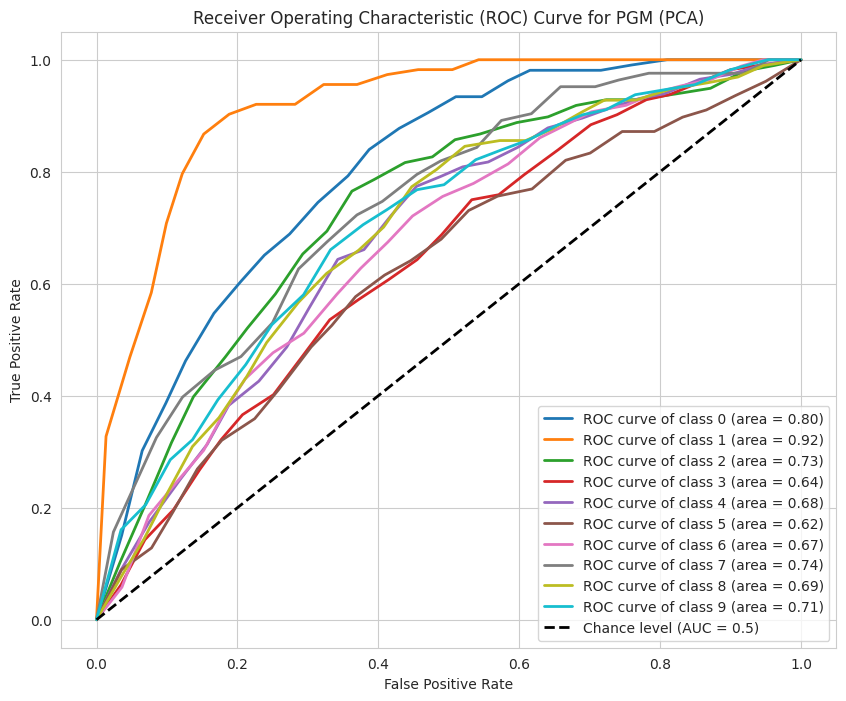

In [224]:
pca_pgm_pred_probs = []

print("Generating PGM (PCA) prediction probabilities for ROC analysis...")
for i, img_raw in enumerate(x_test_subset):
    current_raw_features = extract_quadrant_features(img_raw.squeeze())
    current_raw_features_df = pd.DataFrame([current_raw_features])
    current_pca_features = pca.transform(current_raw_features_df)
    current_pca_features_df = pd.DataFrame(current_pca_features, columns=['PC1', 'PC2'])

    current_discrete_pca_features = {}
    for col in current_pca_features_df.columns:
        current_discrete_pca_features[col] = current_pca_features_df[col].apply(lambda x: discretize_feature(x, col, quantiles_pca_df)).iloc[0]

    query_result = infer_pca.query(variables=['digit_label'], evidence=current_discrete_pca_features)
    pca_pgm_pred_probs.append(query_result.values.flatten())

pca_pgm_pred_probs = np.array(pca_pgm_pred_probs)

# Binarize the true labels for one-vs-rest ROC calculation
label_binarizer = LabelBinarizer()
y_true_binarized_pca = label_binarizer.fit_transform(pca_pgm_true_labels)

# Compute ROC curve and ROC area for each class
fpr_pca = dict()
tpr_pca = dict()
roc_auc_pca = dict()

colors_pca = sns.color_palette('tab10', digit_label_cardinality)

for i in range(digit_label_cardinality):
    if pca_pgm_pred_probs.shape[1] > i:
        fpr_pca[i], tpr_pca[i], _ = roc_curve(y_true_binarized_pca[:, i], pca_pgm_pred_probs[:, i])
        roc_auc_pca[i] = auc(fpr_pca[i], tpr_pca[i])

print("\nAUC for each class (PGM - PCA):")
for i in range(digit_label_cardinality):
    if i in roc_auc_pca:
        print(f"Class {i}: {roc_auc_pca[i]:.2f}")

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
for i, color in zip(range(digit_label_cardinality), colors_pca):
    if i in fpr_pca:
        plt.plot(fpr_pca[i], tpr_pca[i], color=color, lw=2,
                 label=f'ROC curve of class {i} (area = {roc_auc_pca[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance level (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for PGM (PCA)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Task
Improve PGM Feature Engineering: Address the recommendation to improve feature engineering for PGM models, potentially by implementing a 16-region grid or using PCA.

## Evaluate 16-Region PGM

### Subtask:
Generate predictions, classification report, confusion matrix, and ROC AUC for the Bayesian Network model built with 16-region features.


**Reasoning**:
Generate predictions for the entire test subset using the 16-region PGM, calculate the confusion matrix, and print a classification report to evaluate the model's performance. Then visualize the confusion matrix as a heatmap.



In [225]:
pgm_16_regions_predictions = []
pgm_16_regions_pred_probs = []
pgm_16_regions_true_labels = []

print("Generating PGM (16-Region) predictions for the test subset...")
for i, img_raw in enumerate(x_test_subset):
    # Extract 16-region features
    current_raw_features_16_regions = extract_16_region_features(img_raw.squeeze())

    # Discretize the 16-region features
    current_discrete_features_16_regions = {}
    for feature_name, value in current_raw_features_16_regions.items():
        current_discrete_features_16_regions[feature_name] = discretize_feature(value, feature_name, quantiles_16_regions_df)

    # Perform inference
    query_result_16_regions = infer_16_regions.query(variables=['digit_label'], evidence=current_discrete_features_16_regions)
    predicted_label = query_result_16_regions.values.argmax()

    pgm_16_regions_predictions.append(predicted_label)
    pgm_16_regions_pred_probs.append(query_result_16_regions.values.flatten())
    pgm_16_regions_true_labels.append(y_test_subset[i])

print("Predictions generated. Calculating confusion matrix and classification report...")

# Calculate the confusion matrix
cm_16_regions_pgm = confusion_matrix(pgm_16_regions_true_labels, pgm_16_regions_predictions, labels=range(digit_label_cardinality))

# Print classification report
print("\nPGM (16-Region) Classification Report:")
print(classification_report(pgm_16_regions_true_labels, pgm_16_regions_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

print("\nPGM (16-Region) Confusion Matrix:")
print(cm_16_regions_pgm)


# Removed heatmap visualization for PGM (16-Region) as per user request.

Generating PGM (16-Region) predictions for the test subset...
Predictions generated. Calculating confusion matrix and classification report...

PGM (16-Region) Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.74      0.73       106
           1       0.63      0.94      0.75       113
           2       0.87      0.70      0.78        98
           3       0.79      0.64      0.71       112
           4       0.64      0.67      0.65       115
           5       0.74      0.58      0.65        78
           6       0.86      0.87      0.87        86
           7       0.80      0.78      0.79        83
           8       0.66      0.66      0.66        97
           9       0.68      0.64      0.66       112

    accuracy                           0.72      1000
   macro avg       0.74      0.72      0.72      1000
weighted avg       0.73      0.72      0.72      1000


PGM (16-Region) Confusion Matrix:
[[ 78   6   0   1   6  

**Reasoning**:
Compute ROC curve and AUC for each class, and plot them as requested in the subtask.




AUC for each class (PGM - 16-Region):
Class 0: 0.93
Class 1: 0.98
Class 2: 0.96
Class 3: 0.95
Class 4: 0.96
Class 5: 0.95
Class 6: 0.98
Class 7: 0.98
Class 8: 0.93
Class 9: 0.94


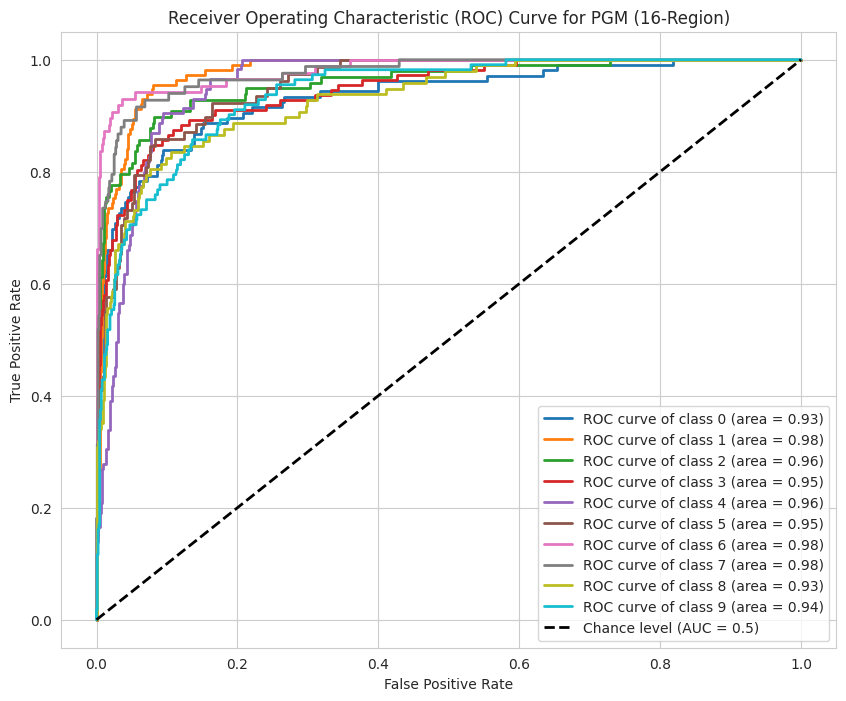

In [226]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc

# Binarize the true labels for one-vs-rest ROC calculation
label_binarizer_16_regions = LabelBinarizer()
y_true_binarized_16_regions = label_binarizer_16_regions.fit_transform(pgm_16_regions_true_labels)

# Convert list of prediction probabilities to a NumPy array
pgm_16_regions_pred_probs = np.array(pgm_16_regions_pred_probs)

# Compute ROC curve and ROC area for each class
fpr_16_regions = dict()
tpr_16_regions = dict()
roc_auc_16_regions = dict()

# Get a distinct color palette for the ROC curves
colors_16_regions = sns.color_palette('tab10', digit_label_cardinality)

for i in range(digit_label_cardinality):
    # Ensure we have probabilities for the current class
    if pgm_16_regions_pred_probs.shape[1] > i:
        fpr_16_regions[i], tpr_16_regions[i], _ = roc_curve(y_true_binarized_16_regions[:, i], pgm_16_regions_pred_probs[:, i])
        roc_auc_16_regions[i] = auc(fpr_16_regions[i], tpr_16_regions[i])


print("\nAUC for each class (PGM - 16-Region):")
for i in range(digit_label_cardinality):
    if i in roc_auc_16_regions:
        print(f"Class {i}: {roc_auc_16_regions[i]:.2f}")

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
for i, color in zip(range(digit_label_cardinality), colors_16_regions):
    if i in fpr_16_regions:
        plt.plot(fpr_16_regions[i], tpr_16_regions[i], color=color, lw=2,
                 label=f'ROC curve of class {i} (area = {roc_auc_16_regions[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance level (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for PGM (16-Region)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Reasoning**:
Convert `pgm_16_regions_pred_probs` to a NumPy array to fix the `AttributeError` and then proceed with ROC curve and AUC calculation.




AUC for each class (PGM - 16-Region):
Class 0: 0.93
Class 1: 0.98
Class 2: 0.96
Class 3: 0.95
Class 4: 0.96
Class 5: 0.95
Class 6: 0.98
Class 7: 0.98
Class 8: 0.93
Class 9: 0.94


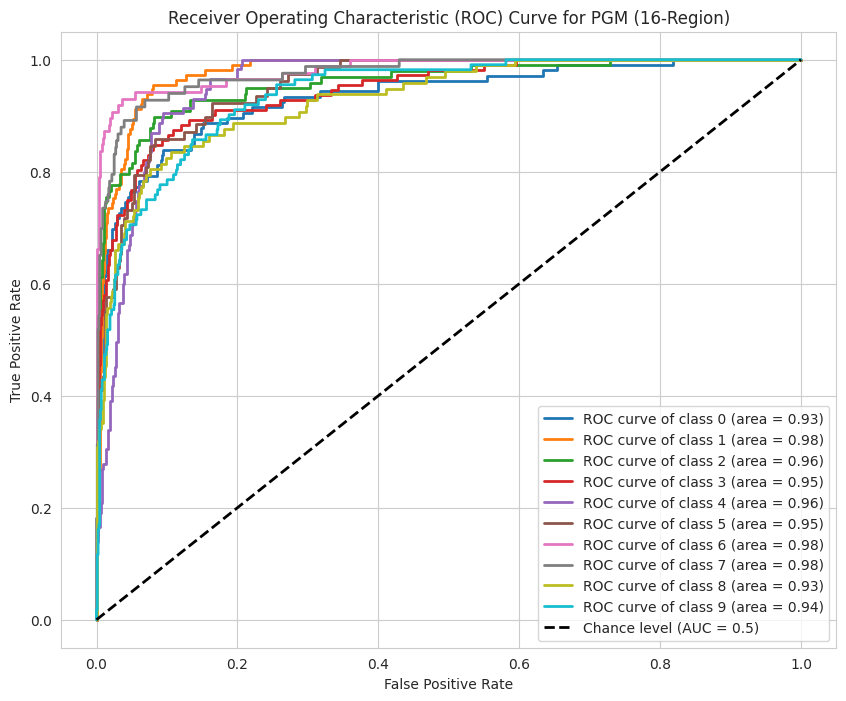

In [227]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc

# Binarize the true labels for one-vs-rest ROC calculation
label_binarizer_16_regions = LabelBinarizer()
y_true_binarized_16_regions = label_binarizer_16_regions.fit_transform(pgm_16_regions_true_labels)

# Convert list of prediction probabilities to a NumPy array
pgm_16_regions_pred_probs = np.array(pgm_16_regions_pred_probs)

# Compute ROC curve and ROC area for each class
fpr_16_regions = dict()
tpr_16_regions = dict()
roc_auc_16_regions = dict()

# Get a distinct color palette for the ROC curves
colors_16_regions = sns.color_palette('tab10', digit_label_cardinality)

for i in range(digit_label_cardinality):
    # Ensure we have probabilities for the current class
    if pgm_16_regions_pred_probs.shape[1] > i:
        fpr_16_regions[i], tpr_16_regions[i], _ = roc_curve(y_true_binarized_16_regions[:, i], pgm_16_regions_pred_probs[:, i])
        roc_auc_16_regions[i] = auc(fpr_16_regions[i], tpr_16_regions[i])


print("\nAUC for each class (PGM - 16-Region):")
for i in range(digit_label_cardinality):
    if i in roc_auc_16_regions:
        print(f"Class {i}: {roc_auc_16_regions[i]:.2f}")

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
for i, color in zip(range(digit_label_cardinality), colors_16_regions):
    if i in fpr_16_regions:
        plt.plot(fpr_16_regions[i], tpr_16_regions[i], color=color, lw=2,
                 label=f'ROC curve of class {i} (area = {roc_auc_16_regions[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance level (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for PGM (16-Region)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Visualizing PGM Model Comparisons (BP, 16-Region, PCA)

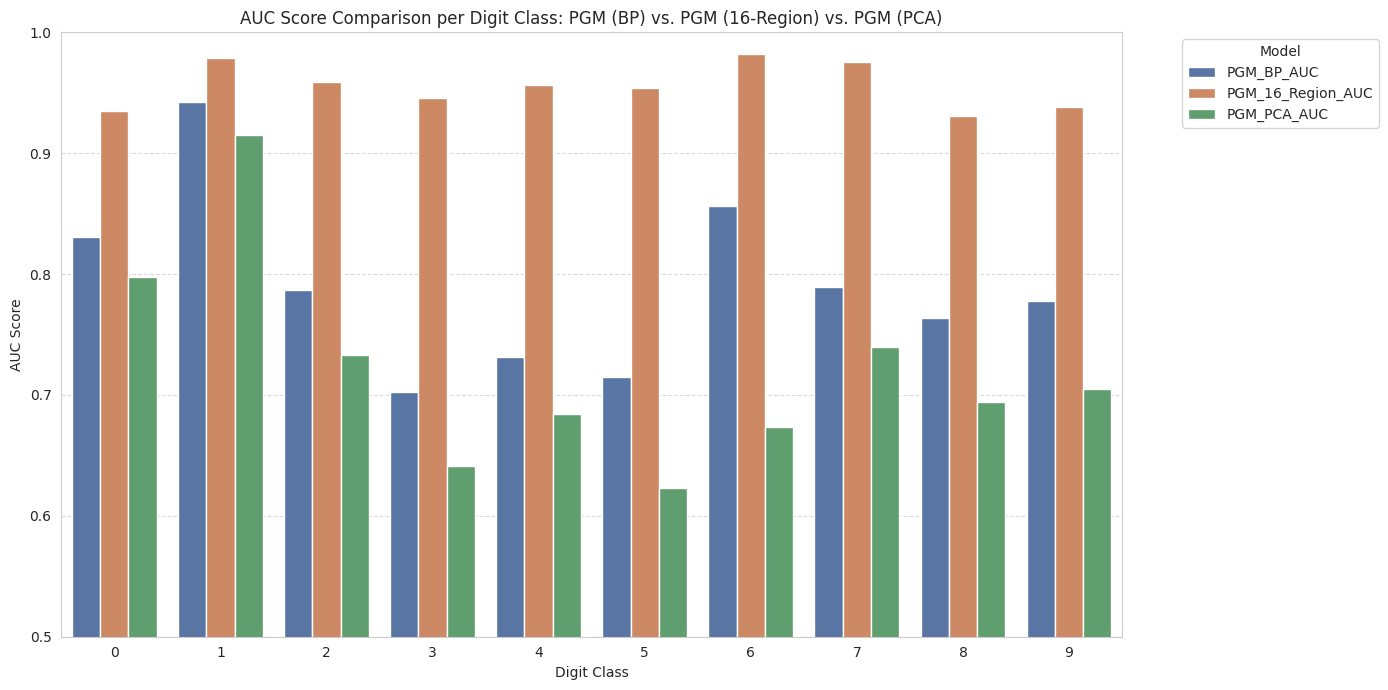

In [228]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract AUCs from previous outputs
# PGM AUCs (from 'roc_auc_bp' dictionary for Belief Propagation)
pgm_bp_auc = [
    roc_auc_bp[i] for i in range(digit_label_cardinality)
]

# PGM AUCs (from 'roc_auc_16_regions' dictionary for 16-Region features)
pgm_16_regions_auc = [
    roc_auc_16_regions[i] for i in range(digit_label_cardinality)
]

# PGM AUCs (from 'roc_auc_pca' dictionary for PCA features)
pgm_pca_auc = [
    roc_auc_pca[i] for i in range(digit_label_cardinality)
]

# Create a DataFrame for AUC comparison per digit class
auc_comparison_all_pgm_df = pd.DataFrame({
    'Digit Class': list(range(digit_label_cardinality)),
    'PGM_BP_AUC': pgm_bp_auc,
    'PGM_16_Region_AUC': pgm_16_regions_auc,
    'PGM_PCA_AUC': pgm_pca_auc
})

# Melt the DataFrame for easier plotting with Seaborn
auc_melted_all_pgm_df = auc_comparison_all_pgm_df.melt(id_vars='Digit Class', var_name='Model', value_name='AUC')

# Plot AUC comparison per digit class for all PGM variations
plt.figure(figsize=(14, 7))
sns.barplot(x='Digit Class', y='AUC', hue='Model', data=auc_melted_all_pgm_df, palette='deep')
plt.title('AUC Score Comparison per Digit Class: PGM (BP) vs. PGM (16-Region) vs. PGM (PCA)')
plt.ylabel('AUC Score')
plt.xlabel('Digit Class')
plt.ylim(0.5, 1) # AUC scores typically range from 0.5 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()